# Notebook 03 — Exploratory Data Analysis & Feature Diagnostics

**Purpose:** understand the raw time-series data before modelling. Decide
which features to keep, identify quality issues, and visualise the fire
signal in the data.

**Inputs:** `full_pixels_10m.csv` (from Notebook 02)
**Outputs:** `selected_features.json`, EDA figures for the thesis

Sections:
1. Descriptive statistics
2. Data-quality diagnostics
3. Correlation and multicollinearity (VIF)
4. Phenomenological visualisation - does the fire signal exist in the data?
5. Feature selection decision


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Mounted at /content/drive


In [2]:
# Load shared configuration.
# config.py must sit at /content/drive/MyDrive/thesis/config.py
import sys, importlib
sys.path.insert(0, "/content/drive/MyDrive/thesis")
import config
importlib.reload(config)

config.ensure_dirs()
config.set_seed()
config.print_summary()


Version:       _10m
GEE project:   bar-project-457815
Scale:         10 m   CRS: EPSG:32636
Period:        2017-2025  (107 months)
S2 collection: projects/bar-project-457815/assets/s2_monthly_image_collection_10m
Features:      27 model inputs (28 total available)
RPS weights:   {'recurrence': 0.25, 'severity': 0.25, 'persistence': 0.25, 'recovery': 0.25}
Seed:          42


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## 1. Load the raw time-series data

In [5]:
df = pd.read_csv(config.FILES["raw_timeseries"])
df = df.sort_values(["pixel_id", "year", "month"]).reset_index(drop=True)

print(f"Rows:    {len(df):,}")
print(f"Pixels:  {df['pixel_id'].nunique():,}")
print(f"Months per pixel (describe):")
print(df.groupby("pixel_id").size().describe())
print()
print("Pixel-type distribution:")
print(df.groupby("pixel_id")["pixel_type"].first().value_counts())


Rows:    992,679
Pixels:  9,667
Months per pixel (describe):
count    9667.000000
mean      102.687390
std         1.679814
min        97.000000
25%       102.000000
50%       103.000000
75%       104.000000
max       106.000000
dtype: float64

Pixel-type distribution:
pixel_type
never_burned     4500
burned_low       4194
burned_medium     773
burned_high       200
Name: count, dtype: int64


## 2. Data-quality diagnostics

### 2.1 NaN heatmap per feature x month

A vertical band indicates a feature that is missing for many pixels in one
month (e.g. heavy cloud cover). A horizontal band indicates a feature with
chronic problems across the whole period.


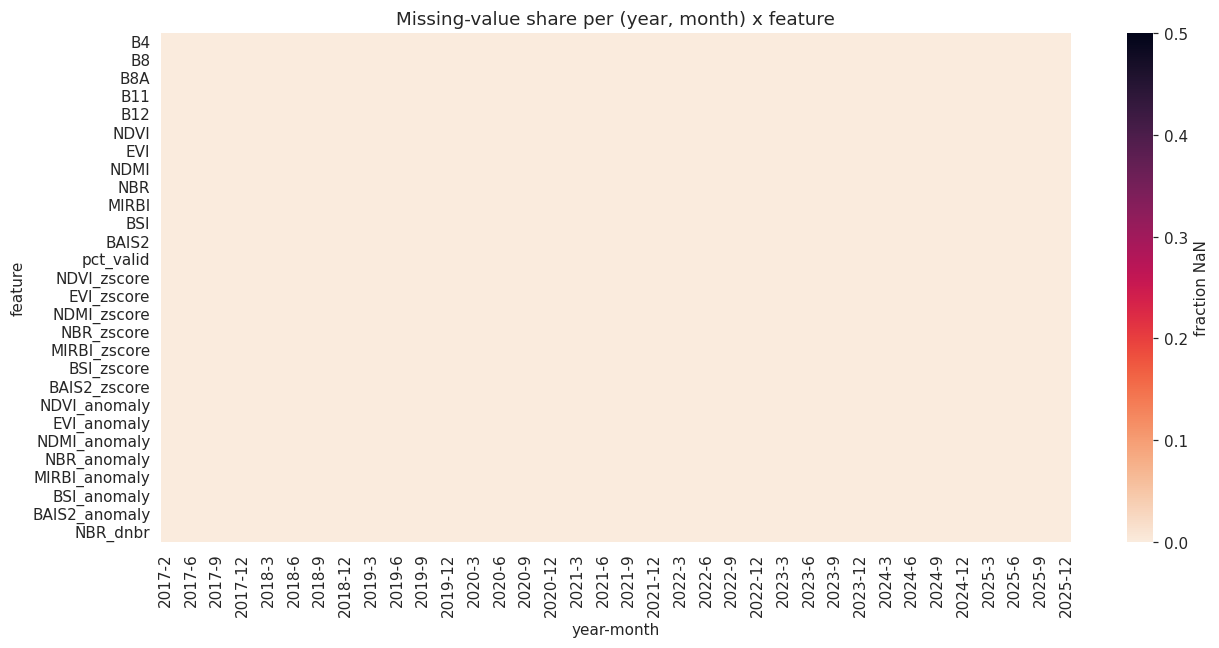

In [5]:
nan_share = (df.groupby(["year", "month"])[config.ALL_FEATURES]
               .apply(lambda g: g.isna().mean()))

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(nan_share.T, ax=ax, cmap="rocket_r", vmin=0, vmax=0.5,
            cbar_kws={"label": "fraction NaN"})
ax.set_title("Missing-value share per (year, month) x feature")
ax.set_xlabel("year-month")
ax.set_ylabel("feature")
plt.tight_layout()
plt.show()


### 2.2 Quality band distribution

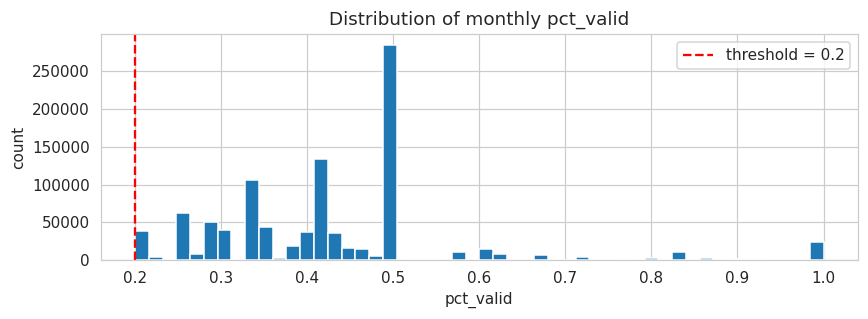

Rows below quality threshold: 0.00%


In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
df["pct_valid"].hist(bins=50, ax=ax, edgecolor="white")
ax.axvline(config.SAMPLING["quality_threshold"], color="red", linestyle="--",
           label=f"threshold = {config.SAMPLING['quality_threshold']}")
ax.set_xlabel("pct_valid")
ax.set_ylabel("count")
ax.set_title("Distribution of monthly pct_valid")
ax.legend()
plt.tight_layout()
plt.show()

below = (df["pct_valid"] < config.SAMPLING["quality_threshold"]).mean()
print(f"Rows below quality threshold: {100*below:.2f}%")


### 2.3 Burned-month statistics

Burned rows: 8,094 (0.815% of all rows)


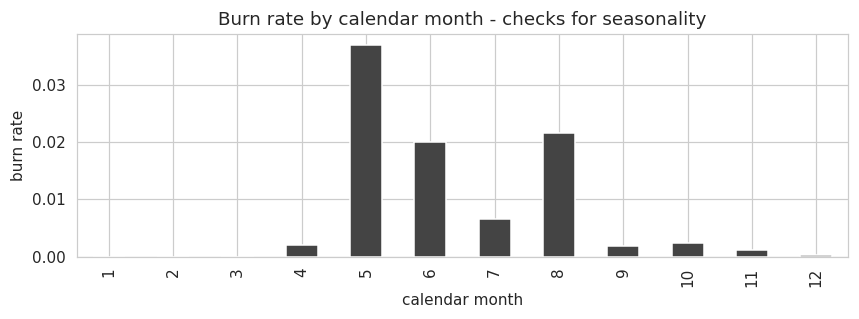

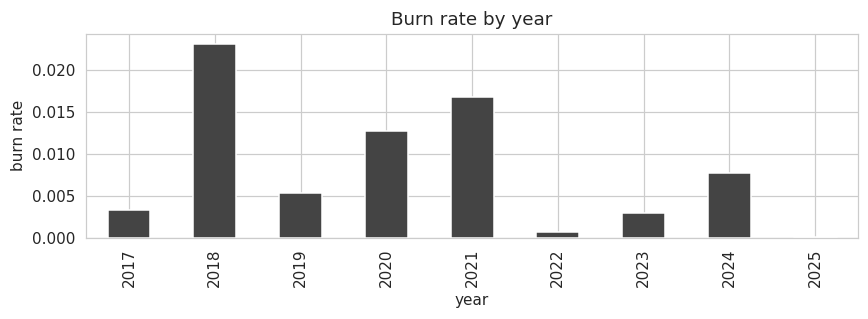

In [7]:
print(f"Burned rows: {df['burned'].sum():,} "
      f"({100*df['burned'].mean():.3f}% of all rows)")

by_month = df.groupby("month")["burned"].mean()
fig, ax = plt.subplots(figsize=(8, 3))
by_month.plot(kind="bar", ax=ax, color="#444")
ax.set_xlabel("calendar month")
ax.set_ylabel("burn rate")
ax.set_title("Burn rate by calendar month - checks for seasonality")
plt.tight_layout()
plt.show()

by_year = df.groupby("year")["burned"].mean()
fig, ax = plt.subplots(figsize=(8, 3))
by_year.plot(kind="bar", ax=ax, color="#444")
ax.set_xlabel("year")
ax.set_ylabel("burn rate")
ax.set_title("Burn rate by year")
plt.tight_layout()
plt.show()


## 3. Correlation and multicollinearity

### 3.1 Correlation matrix (time-averaged per pixel)

Reduce each pixel's time series to its mean so each pixel is a single point
in feature space, then compute pairwise correlations between features.


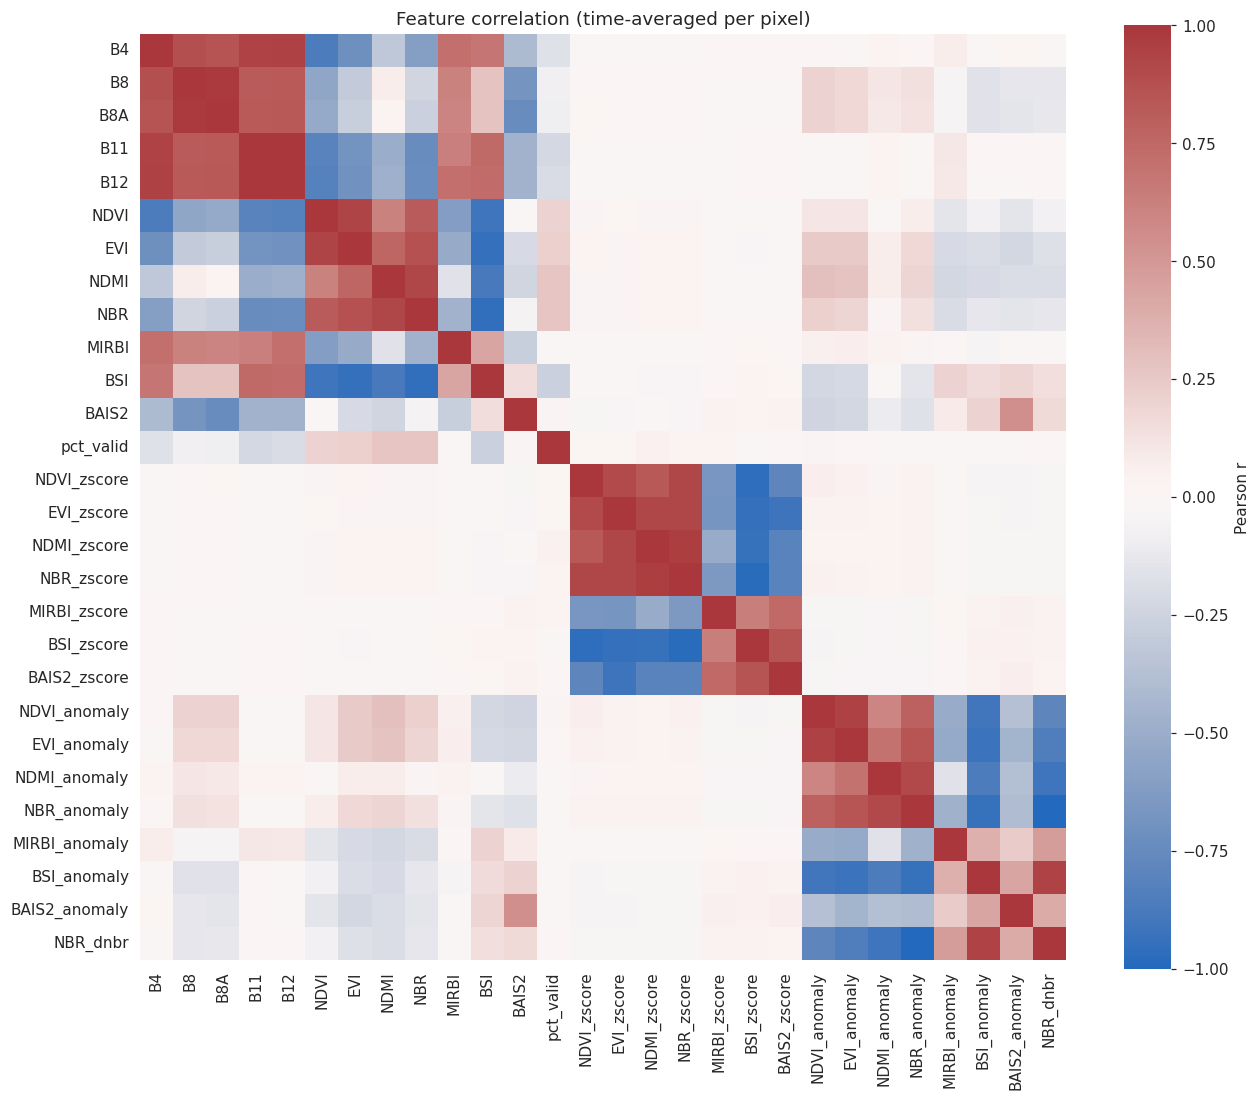

In [8]:
pixel_means = df.groupby("pixel_id")[config.ALL_FEATURES].mean()
corr = pixel_means.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, ax=ax, cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Pearson r"})
ax.set_title("Feature correlation (time-averaged per pixel)")
plt.tight_layout()
plt.show()


### 3.2 Variance Inflation Factor (VIF)

VIF measures how much each feature is explained by the others. VIF above 10
typically indicates problematic multicollinearity. Features with very high
VIF are candidates for removal, but the decision must be driven by ecological
meaning, not just the number.


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = pixel_means[config.ALL_FEATURES].dropna()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()

vif_df = pd.DataFrame({
    "feature": config.ALL_FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(len(config.ALL_FEATURES))],
}).sort_values("VIF", ascending=False)

print(vif_df.to_string(index=False))


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


      feature         VIF
          B11         inf
          B12         inf
        MIRBI         inf
     NBR_dnbr         inf
  NBR_anomaly         inf
          BSI 1498.197927
           B4 1277.793554
           B8 1206.393310
         NDMI  707.246737
          B8A  611.125384
          EVI  519.883408
         NDVI  480.703375
          NBR  356.182620
   NBR_zscore  208.132489
   BSI_zscore  191.144713
  NDMI_zscore  187.567077
  NDVI_zscore   92.113454
  BSI_anomaly   52.789562
   EVI_zscore   45.536916
 NDVI_anomaly   26.596378
  EVI_anomaly   22.053449
 NDMI_anomaly   21.767182
        BAIS2   21.268229
 BAIS2_zscore   14.620091
 MIRBI_zscore    9.825394
BAIS2_anomaly    5.793586
MIRBI_anomaly    4.129977
    pct_valid    1.143610


## 4. Phenomenological visualisation

### 4.1 Inspect example pixels

Plot NBR and NDVI across the full time series for representative pixels:
one that never burned, one that burned once, one that burned many times.
Sanity check - if the fire signal is not visible to the eye, the model will
struggle to learn it.


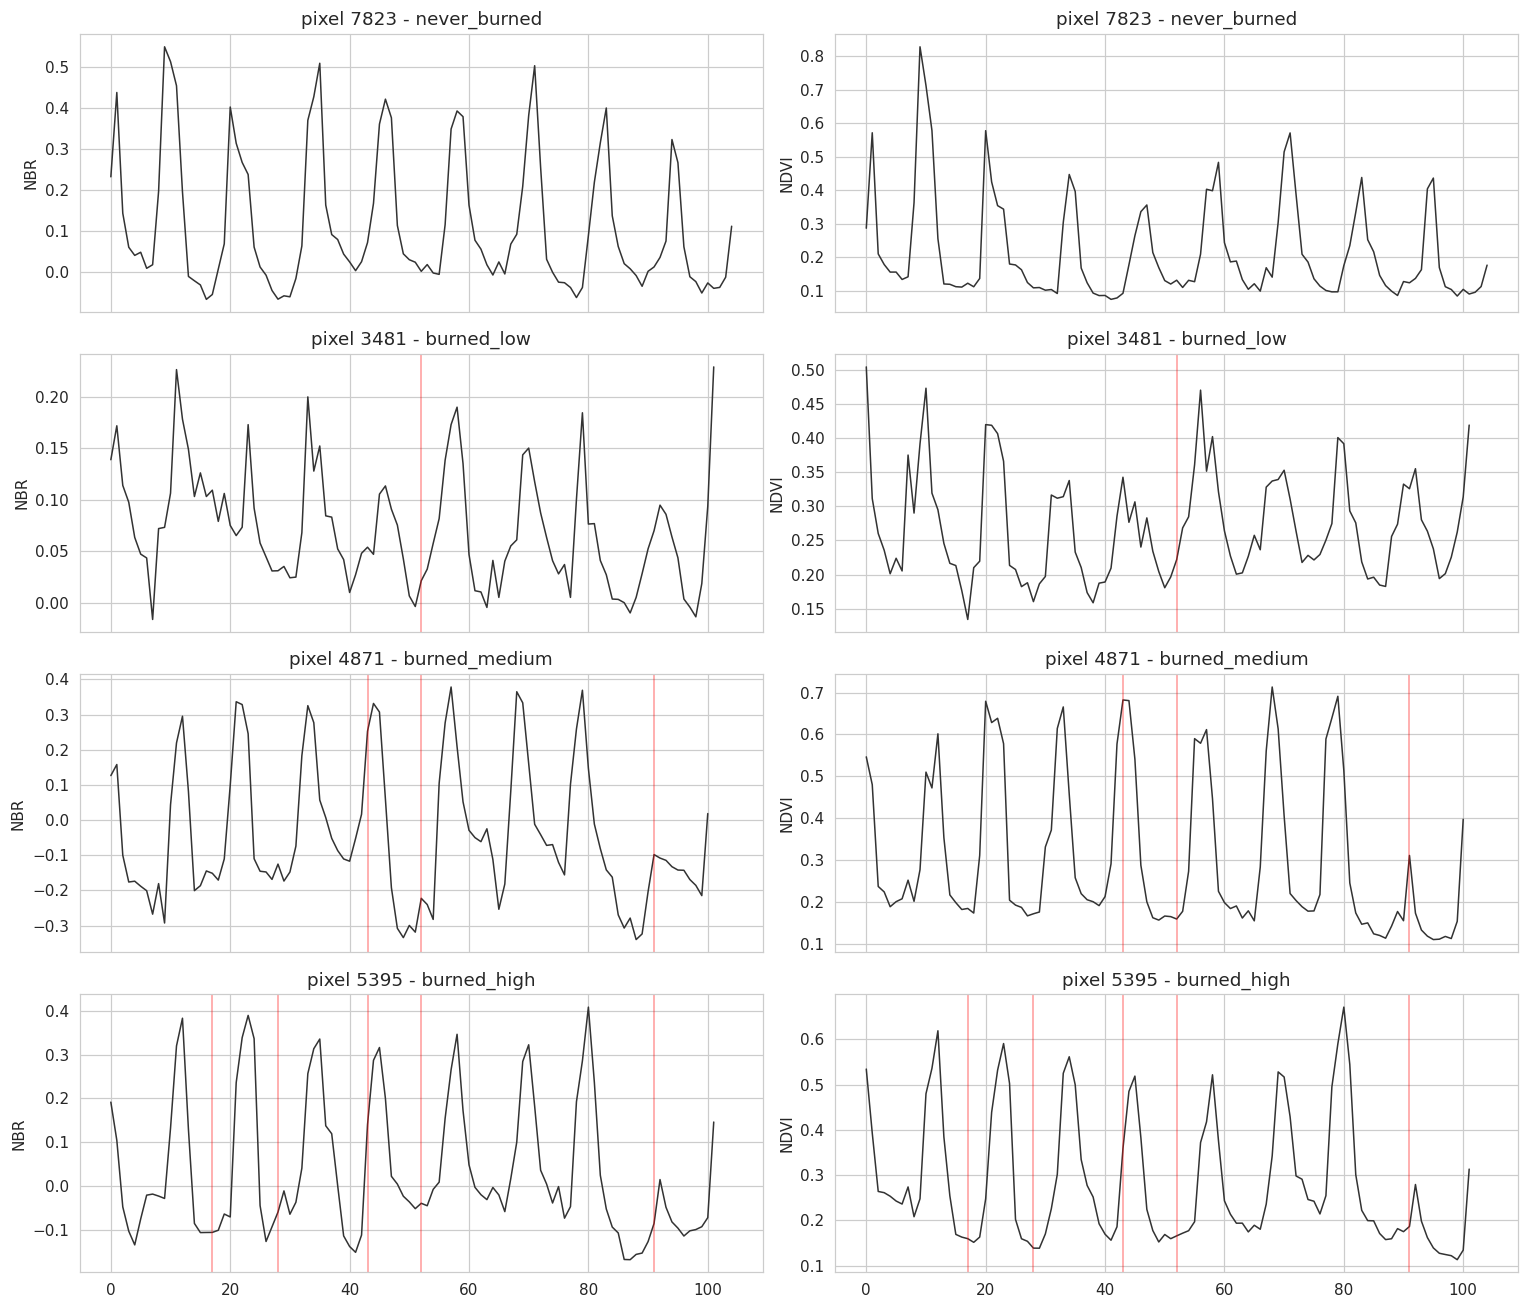

In [10]:
def plot_pixel_timeseries(pid, ax_pair):
    g = df[df["pixel_id"] == pid].sort_values(["year", "month"])
    fire_months = g[g["burned"] == 1]

    for ax, col in zip(ax_pair, ["NBR", "NDVI"]):
        ax.plot(range(len(g)), g[col].values, color="#333", linewidth=1)
        for _, row in fire_months.iterrows():
            t = ((int(row["year"]) - config.START_YEAR) * 12 +
                 (int(row["month"]) - 1))
            ax.axvline(t, color="red", alpha=0.4, linewidth=1)
        ax.set_ylabel(col)
        ax.set_title(f"pixel {pid} - {g['pixel_type'].iloc[0]}")


examples = (df.groupby("pixel_id")
              .agg(pt=("pixel_type", "first"),
                   n_fires=("burned", "sum"))
              .reset_index())

picks = {}
for pt in ["never_burned", "burned_low", "burned_medium", "burned_high"]:
    sub = examples[examples["pt"] == pt]
    if len(sub):
        picks[pt] = sub.sample(1, random_state=config.SEED)["pixel_id"].iloc[0]

fig, axes = plt.subplots(len(picks), 2, figsize=(14, 3 * len(picks)),
                         sharex=True)
for i, (pt, pid) in enumerate(picks.items()):
    plot_pixel_timeseries(pid, axes[i])
plt.tight_layout()
plt.show()


### 4.2 Mean NBR around fire events

For all burned pixels, align time series to the fire month (t=0) and plot
the average NBR trajectory before and after. Shows whether NBR drops as
expected and how long it stays depressed.


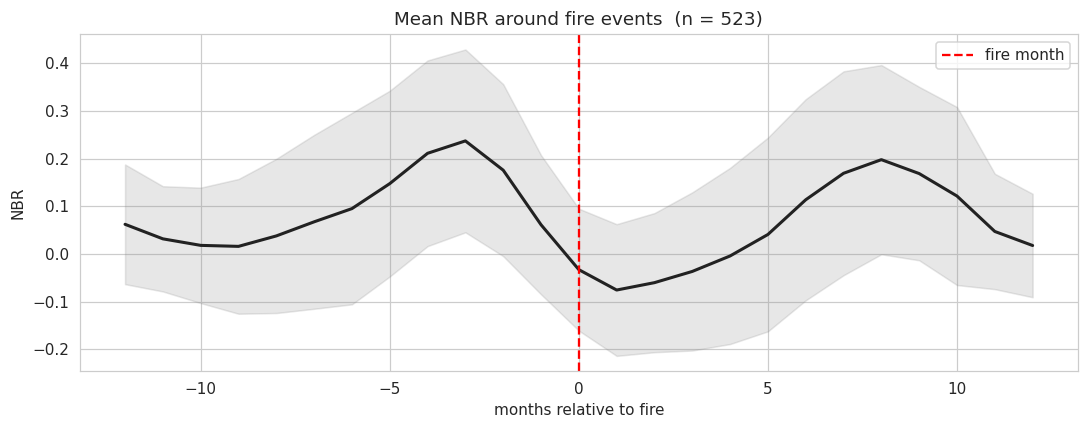

In [11]:
WINDOW = 12
nbr_curves = []

for pid in df[df["burned"] == 1]["pixel_id"].unique()[:500]:
    g = df[df["pixel_id"] == pid].sort_values(["year", "month"])
    nbr = g["NBR"].values
    fires = np.where(g["burned"].values == 1)[0]
    for t in fires:
        lo, hi = t - WINDOW, t + WINDOW + 1
        if lo < 0 or hi > len(nbr):
            continue
        nbr_curves.append(nbr[lo:hi])

nbr_curves = np.array(nbr_curves)
mean = np.nanmean(nbr_curves, axis=0)
std  = np.nanstd(nbr_curves, axis=0)
x    = np.arange(-WINDOW, WINDOW + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, mean, color="#222", linewidth=2)
ax.fill_between(x, mean - std, mean + std, alpha=0.2, color="#888")
ax.axvline(0, color="red", linestyle="--", label="fire month")
ax.set_xlabel("months relative to fire")
ax.set_ylabel("NBR")
ax.set_title(f"Mean NBR around fire events  (n = {len(nbr_curves)})")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Feature selection decision

Based on the diagnostics above, decide which features to keep.

**Default decision:** keep all features in `config.MODEL_FEATURES`. The VIF
table above is documentation, not a hard filter - features with high VIF that
carry distinct ecological information (e.g. NBR vs NBR_zscore) are kept on
purpose. The model's attention mechanism and L2 regularisation handle the
redundancy.
todo- need to select features here- i ran i once with all the features

In [7]:
selected_features = selected_features = [f for f in config.MODEL_FEATURES if f not in ["NBR_dnbr"]] #if I want all features: list(config.MODEL_FEATURES)


with open(config.FILES["selected_features"], "w") as f:
    json.dump({
        "selected": selected_features,
        "rationale": ("All MODEL_FEATURES retained besides NBR_dnbr; redundancy handled by "
                      "attention and L2 regularisation. VIF documented for "
                      "thesis discussion."),
    }, f, indent=2)

print(f"Wrote {len(selected_features)} features to "
      f"{config.FILES['selected_features']}")


Wrote 26 features to /content/drive/MyDrive/thesis/data/eda/selected_features.json


In [8]:
with open(config.FILES["selected_features"]) as f:
    sel = json.load(f)
print(f"Number of selected features: {len(sel['selected'])}")
print(f"NBR_dnbr in list? {'NBR_dnbr' in sel['selected']}")
print(sel["selected"])

Number of selected features: 26
NBR_dnbr in list? False
['B4', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'EVI', 'NDMI', 'NBR', 'MIRBI', 'BSI', 'BAIS2', 'NDVI_zscore', 'EVI_zscore', 'NDMI_zscore', 'NBR_zscore', 'MIRBI_zscore', 'BSI_zscore', 'BAIS2_zscore', 'NDVI_anomaly', 'EVI_anomaly', 'NDMI_anomaly', 'NBR_anomaly', 'MIRBI_anomaly', 'BSI_anomaly', 'BAIS2_anomaly']
